# Estatistica, Probabilidade e Previsao

## Live 3 - Applied Math for Data Science

Nesta aula, vamos comparar dois jeitos de prever o futuro em series temporais:

- **Regressao linear** para capturar tendencia global
- **ARIMA** para capturar dependencia temporal

O caso da aula sera a previsao de usuarios ativos mensais de uma plataforma de IA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA

plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4, suppress=True)
warnings.filterwarnings('ignore')

print('Ambiente pronto para previsao temporal.')

Ambiente pronto para previsao temporal.


---

## 1. Criando uma serie temporal com tendencia, sazonalidade e ruido

Vamos simular 72 meses de atividade de uma plataforma. A serie tem:

- crescimento estrutural
- oscilacao sazonal ao longo do ano
- ruido aleatorio

In [2]:
rng = np.random.default_rng(7)
meses = np.arange(72)

tendencia = 200 + 4.5 * meses
sazonalidade = 28 * np.sin(2 * np.pi * meses / 12)
ruido = rng.normal(0, 8, size=len(meses))

serie = tendencia + sazonalidade + ruido

print(f'Tamanho da serie: {len(serie)} meses')
print(f'Media: {np.mean(serie):.2f}')
print(f'Desvio padrao: {np.std(serie):.2f}')

Tamanho da serie: 72 meses
Media: 357.96
Desvio padrao: 94.20


In [3]:
serie

array([200.0098, 220.89  , 231.0556, 234.3753, 238.6113, 228.5668,
       227.4811, 228.2217, 207.8136, 207.5362, 224.67  , 238.3551,
       254.8433, 265.0563, 287.0147, 301.0624, 285.495 , 286.8391,
       265.7902, 261.1837, 251.0174, 264.6193, 264.6117, 291.6701,
       309.254 , 325.0046, 321.1146, 345.1905, 349.8607, 345.4065,
       322.7589, 321.678 , 311.9231, 314.0293, 337.2385, 337.0397,
       361.7398, 387.5751, 390.5799, 402.6064, 405.1324, 399.0103,
       379.1996, 380.1091, 384.6219, 362.1228, 389.6264, 398.4548,
       410.8682, 450.5033, 455.3468, 447.9057, 458.8448, 457.1135,
       441.4897, 438.9633, 427.2192, 433.838 , 448.2595, 446.0947,
       471.6251, 484.7935, 504.2669, 502.0024, 507.6143, 504.9304,
       504.1901, 496.6618, 471.1631, 476.1429, 495.9265, 489.5606])

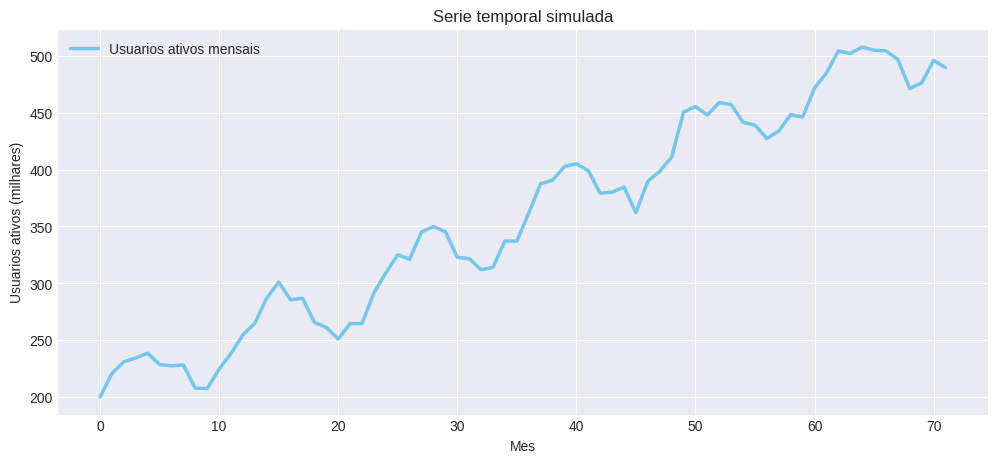

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(meses, serie, color='#74c7ec', linewidth=2.5, label='Usuarios ativos mensais')
plt.title('Serie temporal simulada')
plt.xlabel('Mes')
plt.ylabel('Usuarios ativos (milhares)')
plt.legend()
plt.show()

### Leitura estatistica rapida

Em previsao, a estatistica entra primeiro para responder:

- ha crescimento?
- ha repeticao sazonal?
- o ruido parece pequeno ou grande?

Sem essa leitura, escolher um modelo vira tentativa e erro.

### Exemplos de vida real para previsao

Forecast aparece em muitos produtos e operacoes reais:

- **E-commerce**: prever demanda futura para ajustar estoque
- **Fintech**: prever transacoes por hora para evitar sobrecarga
- **Mobilidade**: prever corridas ou trafego em horarios de pico
- **Saude**: prever ocupacao de leitos e consumo de insumos
- **Plataformas de IA**: prever uso de GPU e numero de requisicoes

Nesta aula, vamos usar o ultimo caso: crescimento de usuarios ativos mensais de uma plataforma de IA.

---

## 2. Separando treino e teste

Vamos treinar com os primeiros 60 meses e testar nos 12 meses finais.

In [5]:
train_size = 60
x_train = meses[:train_size]
y_train = serie[:train_size]
x_test = meses[train_size:]
y_test = serie[train_size:]

print(f'Treino: {len(y_train)} pontos')
print(f'Teste: {len(y_test)} pontos')

Treino: 60 pontos
Teste: 12 pontos


---

## 3. Antes do ARIMA: comecando pelo ARMA

Antes de falar de ARIMA, vale separar as pecas:

- **AR (AutoRegressive)**: o valor atual depende de valores passados da propria serie
- **MA (Moving Average)**: o valor atual depende dos erros passados
- **ARMA**: combina os dois, assumindo uma serie mais estavel

Esquematicamente:

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots$$

### O que o I resolve

ARMA puro sofre quando a serie tem tendencia forte. O `I` de ARIMA vem de **Integrated** e, na pratica, significa diferenciar a serie:

$$\Delta y_t = y_t - y_{t-1}$$

Se uma diferenca nao bastar, podemos aplicar de novo:

$$\Delta^2 y_t = \Delta y_t - \Delta y_{t-1}$$

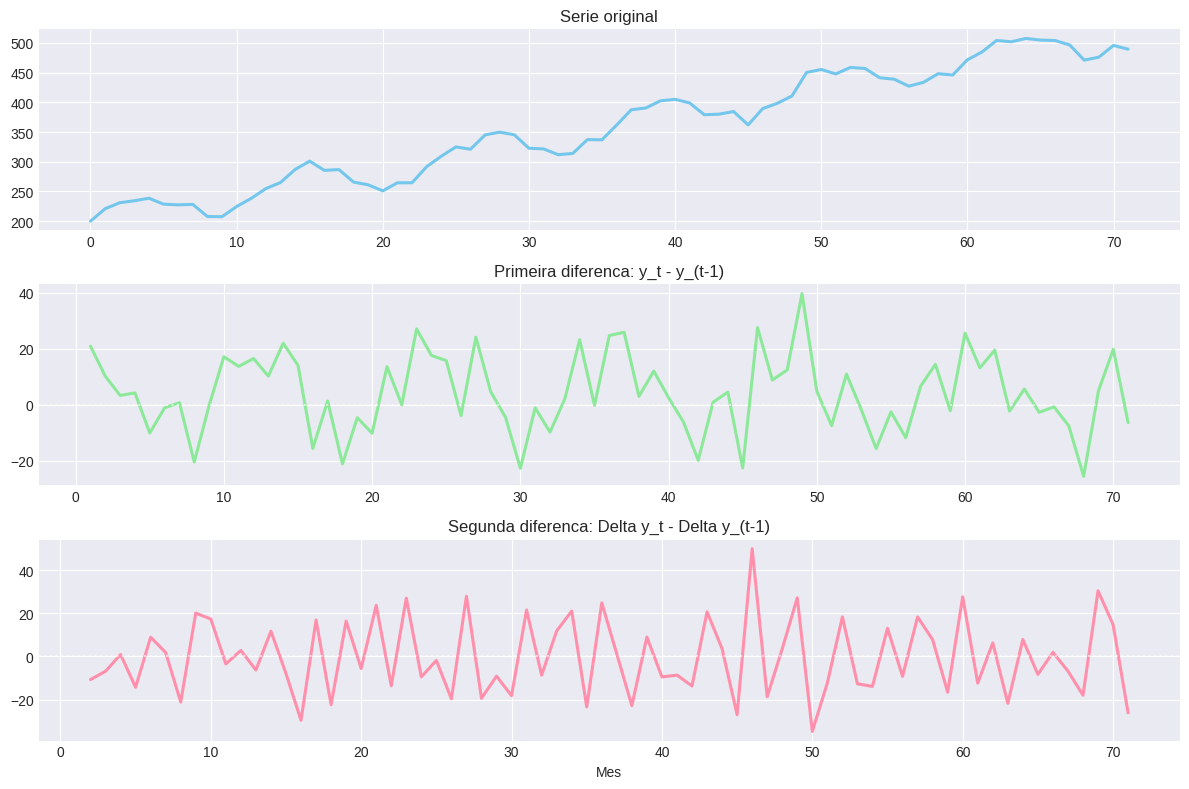

In [6]:
primeira_diferenca = np.diff(serie, n=1)
segunda_diferenca = np.diff(serie, n=2)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(meses, serie, color='#74c7ec', linewidth=2.2)
axes[0].set_title('Serie original')

axes[1].plot(meses[1:], primeira_diferenca, color='#8ce99a', linewidth=2.2)
axes[1].axhline(0, color='white', linestyle=':', alpha=0.6)
axes[1].set_title('Primeira diferenca: y_t - y_(t-1)')

axes[2].plot(meses[2:], segunda_diferenca, color='#ff8fab', linewidth=2.2)
axes[2].axhline(0, color='white', linestyle=':', alpha=0.6)
axes[2].set_title('Segunda diferenca: Delta y_t - Delta y_(t-1)')
axes[2].set_xlabel('Mes')

plt.tight_layout()
plt.show()

### Como o MA funciona

O `MA` nao e uma media movel simples dos dados observados. Ele usa os **erros passados** para corrigir a previsao atual:

$$y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots$$

Se o modelo errou para cima ou para baixo recentemente, isso pode carregar informacao util para o instante atual.

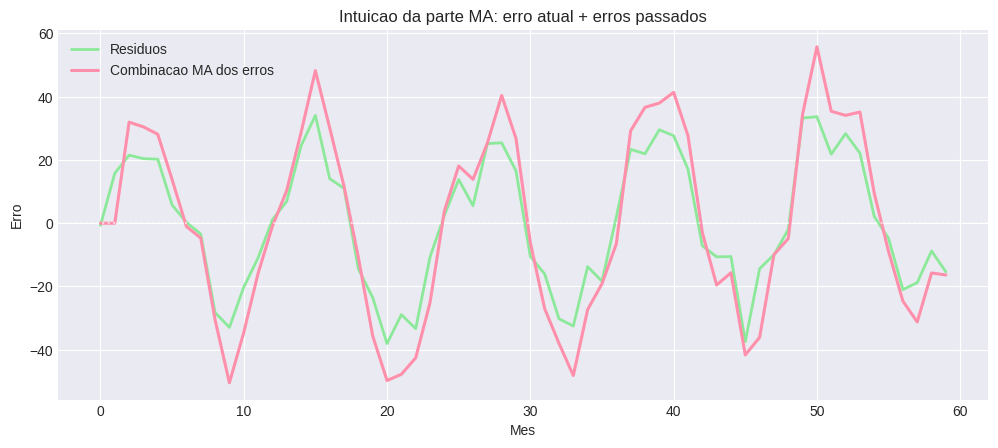

In [7]:
coef_base = np.polyfit(x_train, y_train, deg=1)
base_train = coef_base[0] * x_train + coef_base[1]
residuos_base = y_train - base_train

theta1 = 0.65
theta2 = -0.25
efeito_ma = np.zeros_like(residuos_base)
for t in range(2, len(residuos_base)):
    efeito_ma[t] = residuos_base[t] + theta1 * residuos_base[t - 1] + theta2 * residuos_base[t - 2]

plt.figure(figsize=(12, 4.8))
plt.plot(x_train, residuos_base, color='#8ce99a', linewidth=2, label='Residuos')
plt.plot(x_train, efeito_ma, color='#ff8fab', linewidth=2.2, label='Combinacao MA dos erros')
plt.axhline(0, color='white', linestyle=':', alpha=0.6)
plt.title('Intuicao da parte MA: erro atual + erros passados')
plt.xlabel('Mes')
plt.ylabel('Erro')
plt.legend()
plt.show()

---

## 4. Previsao com regressao linear

Aqui tratamos o tempo como variavel explicativa. O modelo procura a melhor reta:

$$y_t = a + bt$$

In [8]:
coef = np.polyfit(x_train, y_train, deg=1)
slope, intercept = coef[0], coef[1]

pred_train_reg = slope * x_train + intercept
pred_test_reg = slope * x_test + intercept

print(f'Inclinação estimada: {slope:.3f}')
print(f'Intercepto estimado: {intercept:.3f}')

Inclinação estimada: 4.420
Intercepto estimado: 200.700


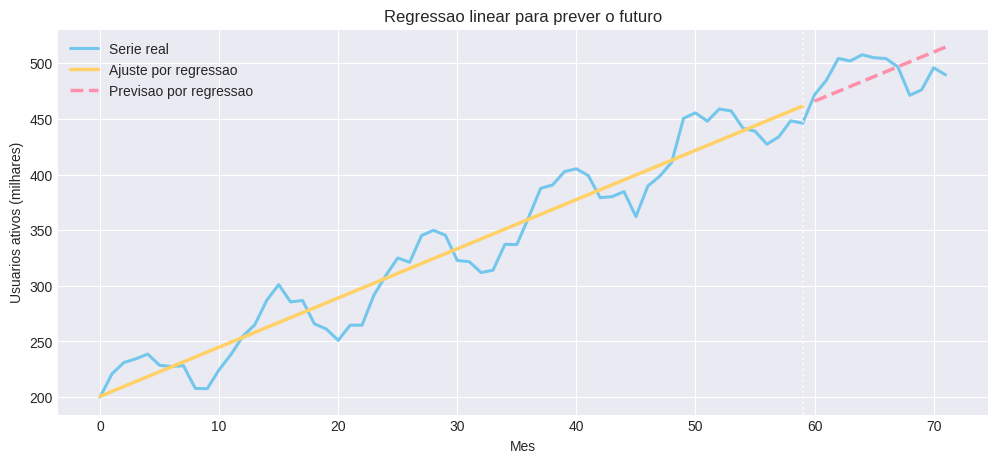

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(meses, serie, color='#74c7ec', linewidth=2.2, label='Serie real')
plt.plot(x_train, pred_train_reg, color='#ffd166', linewidth=2.5, label='Ajuste por regressao')
plt.plot(x_test, pred_test_reg, color='#ff8fab', linewidth=2.5, linestyle='--', label='Previsao por regressao')
plt.axvline(train_size - 1, color='white', linestyle=':', alpha=0.7)
plt.title('Regressao linear para prever o futuro')
plt.xlabel('Mes')
plt.ylabel('Usuarios ativos (milhares)')
plt.legend()
plt.show()

### Limite da regressao

Ela enxerga bem a direcao geral da serie, mas ignora memoria curta e estrutura dos erros.

---

## 5. Previsao com ARIMA

Agora juntamos tudo:

- o `I` diferencia a serie
- o `AR` usa valores passados
- o `MA` usa erros passados

Em resumo, **ARIMA e um ARMA aplicado sobre uma serie diferenciada**.

Agora usamos um modelo que considera o passado da propria serie.

Vamos testar um **ARIMA(2, 2, 3)** para capturar dinamica temporal e diferencas sucessivas da serie.

In [10]:
modelo_arima = ARIMA(y_train, order=(2, 2, 3))
resultado_arima = modelo_arima.fit()

pred_test_arima = resultado_arima.forecast(steps=len(y_test))

print(resultado_arima.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7312      0.028     61.958      0.000       1.676       1.786
ar.L2         -0.9996      0.008   -122.188      0.000      -1.016      -0.984
ma.L1         -2.7190     15.302     -0.178      0.859     -32.711      27.273
ma.L2          2.7190     15.324      0.177      0.859     -27.315      32.753
ma.L3         -0.9999      0.273     -3.660      0.000      -1.535      -0.464
sigma2       105.2224      0.146    720.788      0.000     104.936     105.509


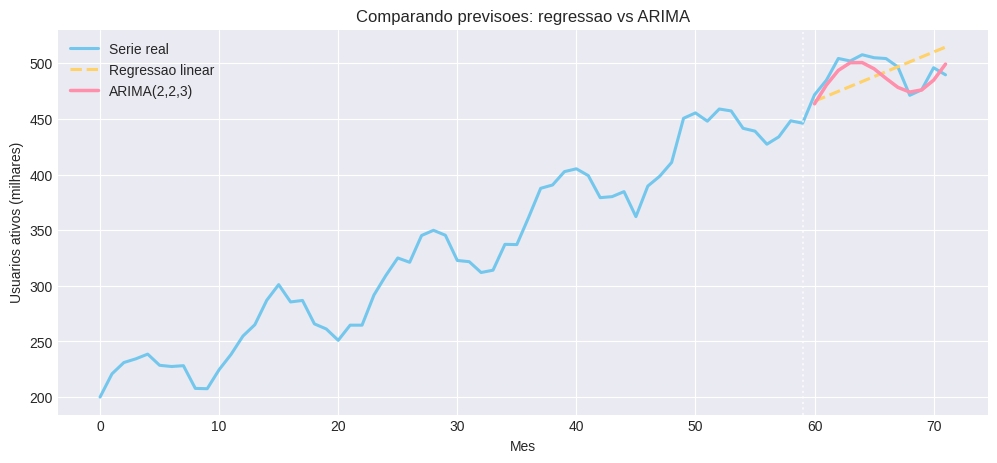

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(meses, serie, color='#74c7ec', linewidth=2.2, label='Serie real')
plt.plot(x_test, pred_test_reg, color='#ffd166', linewidth=2.2, linestyle='--', label='Regressao linear')
plt.plot(x_test, pred_test_arima, color='#ff8fab', linewidth=2.5, label='ARIMA(2,2,3)')
plt.axvline(train_size - 1, color='white', linestyle=':', alpha=0.7)
plt.title('Comparando previsoes: regressao vs ARIMA')
plt.xlabel('Mes')
plt.ylabel('Usuarios ativos (milhares)')
plt.legend()
plt.show()

---

## 6. Medindo erro de previsao

Vamos usar o **MAE** (erro absoluto medio) para comparar os modelos.

In [12]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

mae_reg = mae(y_test, pred_test_reg)
mae_arima = mae(y_test, pred_test_arima)

print(f'MAE regressao linear: {mae_reg:.3f}')
print(f'MAE ARIMA: {mae_arima:.3f}')

MAE regressao linear: 18.691
MAE ARIMA: 8.472


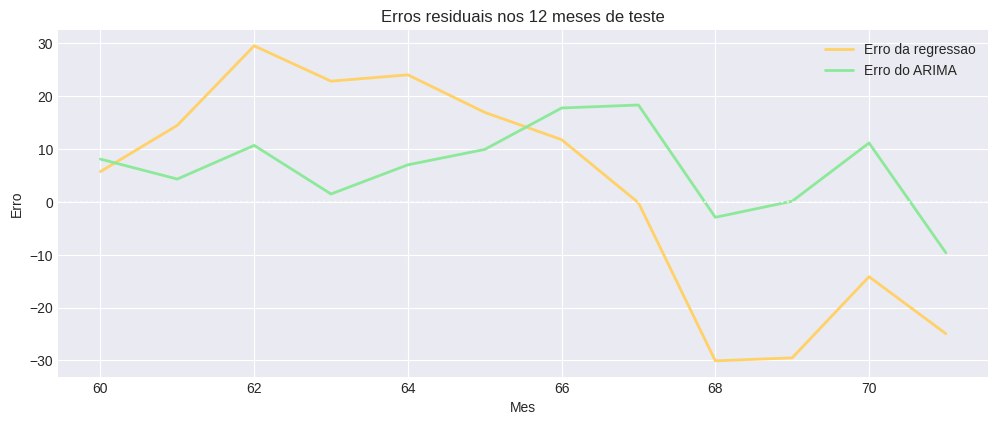

In [13]:
erros_reg = y_test - pred_test_reg
erros_arima = y_test - pred_test_arima

plt.figure(figsize=(12, 4.5))
plt.plot(x_test, erros_reg, color='#ffd166', linewidth=2, label='Erro da regressao')
plt.plot(x_test, erros_arima, color='#8ce99a', linewidth=2, label='Erro do ARIMA')
plt.axhline(0, color='white', linestyle=':', alpha=0.7)
plt.title('Erros residuais nos 12 meses de teste')
plt.xlabel('Mes')
plt.ylabel('Erro')
plt.legend()
plt.show()

### Leitura probabilistica

Os residuos representam a parte que o modelo nao explicou.

Em estatistica aplicada, eles ajudam a responder:
- o erro parece centrado em zero?
- o modelo esta enviesado?
- a incerteza cresce com o horizonte de previsao?

---

## 7. Fazendo uma previsao para frente

Agora vamos ajustar o ARIMA na serie completa e projetar os proximos 12 meses.

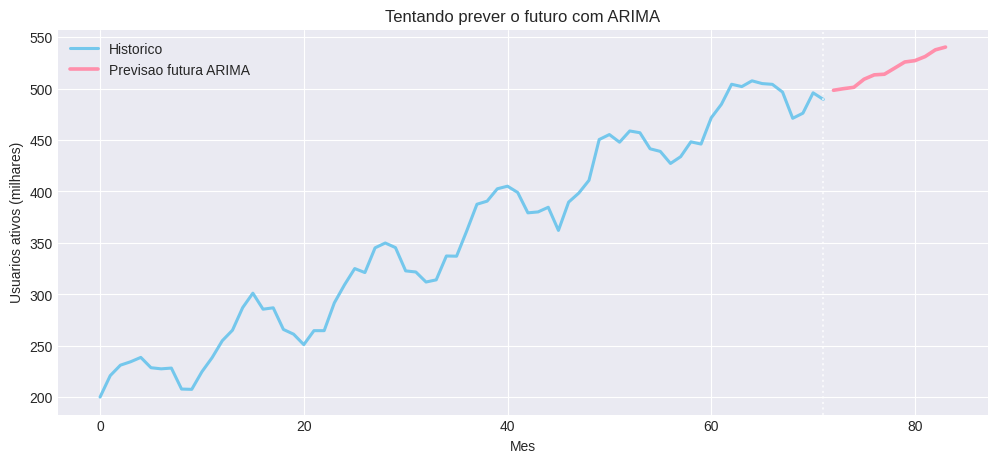

In [14]:
modelo_final = ARIMA(serie, order=(2, 2, 3))
resultado_final = modelo_final.fit()

horizonte = 12
futuro_x = np.arange(len(serie), len(serie) + horizonte)
futuro_y = resultado_final.forecast(steps=horizonte)

plt.figure(figsize=(12, 5))
plt.plot(meses, serie, color='#74c7ec', linewidth=2.2, label='Historico')
plt.plot(futuro_x, futuro_y, color='#ff8fab', linewidth=2.6, label='Previsao futura ARIMA')
plt.axvline(len(serie) - 1, color='white', linestyle=':', alpha=0.7)
plt.title('Tentando prever o futuro com ARIMA')
plt.xlabel('Mes')
plt.ylabel('Usuarios ativos (milhares)')
plt.legend()
plt.show()

---

## 9. Distribuicao probabilistica dos residuos

A previsao nunca e perfeita. O que sobra — o **residuo** — carrega informacao probabilistica importante.

Se o modelo esta bem calibrado, os residuos devem:

- ter **media proxima de zero** (sem vies sistematico)
- seguir uma **distribuicao normal** (ruido aleatorio puro)
- nao exibir **padrao temporal** (ausencia de autocorrelacao)

Vamos verificar isso com tres ferramentas:

| Ferramenta | O que revela |
|---|---|
| Histograma + curva normal | Formato da distribuicao |
| QQ-plot | Aderencia a normalidade |
| Teste de Shapiro-Wilk | Teste formal de normalidade |

Media dos residuos:      6.3857
Desvio padrao:           7.8545
Assimetria (skewness):   -0.3136
Curtose (kurtosis):      -0.5116
Shapiro-Wilk (p-valor):  0.9080

Residuos consistentes com distribuicao normal (p > 0.05)


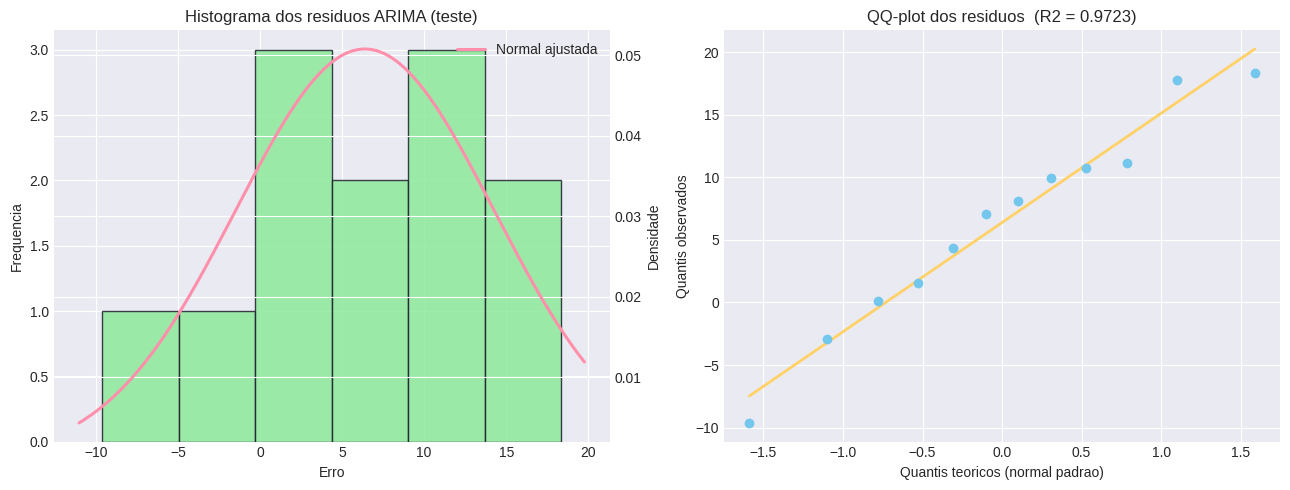

In [15]:
from scipy import stats

residuos_arima = y_test - pred_test_arima

media_res = np.mean(residuos_arima)
std_res   = np.std(residuos_arima)
skew_res  = stats.skew(residuos_arima)
kurt_res  = stats.kurtosis(residuos_arima)
_, p_shapiro = stats.shapiro(residuos_arima)

print(f'Media dos residuos:      {media_res:.4f}')
print(f'Desvio padrao:           {std_res:.4f}')
print(f'Assimetria (skewness):   {skew_res:.4f}')
print(f'Curtose (kurtosis):      {kurt_res:.4f}')
print(f'Shapiro-Wilk (p-valor):  {p_shapiro:.4f}')
print()
if p_shapiro > 0.05:
    print('Residuos consistentes com distribuicao normal (p > 0.05)')
else:
    print('Residuos divergem da normalidade (p <= 0.05)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(residuos_arima, bins=6, color='#8ce99a', edgecolor='#1e1e2e', alpha=0.85)
xmin, xmax = axes[0].get_xlim()
xs = np.linspace(xmin, xmax, 200)
pdf = stats.norm.pdf(xs, media_res, std_res)
ax2 = axes[0].twinx()
ax2.plot(xs, pdf, color='#ff8fab', linewidth=2.2, label='Normal ajustada')
ax2.set_ylabel('Densidade')
ax2.legend(loc='upper right')
axes[0].set_title('Histograma dos residuos ARIMA (teste)')
axes[0].set_xlabel('Erro')
axes[0].set_ylabel('Frequencia')

# QQ-plot
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(residuos_arima, dist='norm')
axes[1].scatter(osm, osr, color='#74c7ec', zorder=3)
line_y = slope_qq * np.array([osm[0], osm[-1]]) + intercept_qq
axes[1].plot([osm[0], osm[-1]], line_y, color='#ffd166', linewidth=2)
axes[1].set_title(f'QQ-plot dos residuos  (R2 = {r_qq**2:.4f})')
axes[1].set_xlabel('Quantis teoricos (normal padrao)')
axes[1].set_ylabel('Quantis observados')

plt.tight_layout()
plt.show()

### Interpretacao dos resultados

- **Histograma**: residuos se concentram em torno de zero com formato aproximadamente simetrico.
- **QQ-plot**: pontos proximos da reta diagonal indicam normalidade. Desvios nas extremidades sao comuns com amostras pequenas.
- **Shapiro-Wilk**: p > 0,05 e o criterio usual para nao rejeitar a normalidade.

Quando os residuos sao normais, podemos usar a teoria estatistica classica para calcular **intervalos de confianca** na previsao.

---

## 10. Intervalo de confianca na previsao

Uma previsao pontual diz "o valor sera X". Mas isso ignora a **incerteza do modelo**.

O **intervalo de confianca** (IC) comunica a faixa plausivel de valores futuros dado um nivel de confianca:

$$\hat{y}_t \pm z_{\alpha/2} \cdot \hat{\sigma}_t$$

- Para IC 95%: $z_{\alpha/2} = 1{,}96$
- $\hat{\sigma}_t$ cresce com o horizonte: prever longe e mais incerto

O `statsmodels` calcula isso automaticamente via `get_forecast()`.

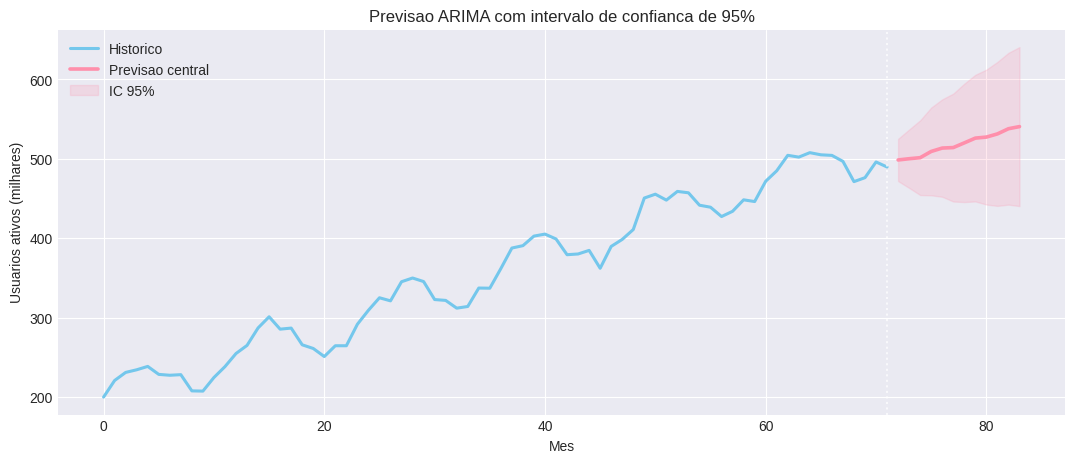

Previsoes com IC 95%:
  Mes 73: 498.4  [471.9, 525.0]
  Mes 74: 500.0  [463.3, 536.7]
  Mes 75: 501.3  [454.3, 548.3]
  Mes 76: 509.2  [453.9, 564.4]
  Mes 77: 513.4  [452.1, 574.7]
  Mes 78: 514.0  [446.1, 581.9]
  Mes 79: 519.9  [445.5, 594.4]
  Mes 80: 525.9  [446.2, 605.6]
  Mes 81: 527.2  [442.3, 612.2]
  Mes 82: 531.2  [440.6, 621.8]
  Mes 83: 537.7  [442.2, 633.2]
  Mes 84: 540.4  [440.4, 640.5]


In [16]:
previsao_final = resultado_final.get_forecast(steps=horizonte)
ci = previsao_final.conf_int(alpha=0.05)
y_medio  = previsao_final.predicted_mean
# conf_int pode retornar DataFrame ou ndarray dependendo da versao do statsmodels
if hasattr(ci, 'iloc'):
    ci_lower = ci.iloc[:, 0].values
    ci_upper = ci.iloc[:, 1].values
else:
    ci_lower = ci[:, 0]
    ci_upper = ci[:, 1]

if hasattr(y_medio, 'values'):
    y_medio_vals = y_medio.values
else:
    y_medio_vals = np.asarray(y_medio)

plt.figure(figsize=(13, 5))
plt.plot(meses, serie, color='#74c7ec', linewidth=2.2, label='Historico')
plt.plot(futuro_x, y_medio_vals, color='#ff8fab', linewidth=2.6, label='Previsao central')
plt.fill_between(futuro_x, ci_lower, ci_upper, color='#ff8fab', alpha=0.20, label='IC 95%')
plt.axvline(len(serie) - 1, color='white', linestyle=':', alpha=0.7)
plt.title('Previsao ARIMA com intervalo de confianca de 95%')
plt.xlabel('Mes')
plt.ylabel('Usuarios ativos (milhares)')
plt.legend()
plt.show()

print('Previsoes com IC 95%:')
for i in range(horizonte):
    print(f'  Mes {len(serie)+i+1}: {y_medio_vals[i]:.1f}  [{ci_lower[i]:.1f}, {ci_upper[i]:.1f}]')

### O que o IC nos diz

- A **faixa sombreada** mostra onde esperamos que o valor caia com 95% de probabilidade.
- O intervalo **cresce com o horizonte**: prever mais longe acumula mais incerteza.
- Em producao, decisoes de infraestrutura e estoque devem considerar o **limite superior** do IC, nao apenas o valor central.

---

## 11. Escolhendo a ordem do ARIMA via AIC

Como decidir os valores de `p`, `d` e `q`?

O criterio **AIC (Akaike Information Criterion)** penaliza a complexidade do modelo:

$$AIC = 2k - 2\ln(\hat{L})$$

- `k`: numero de parametros estimados
- $\hat{L}$: verossimilhanca maximizada

**Menor AIC = melhor equilibrio entre ajuste e parcimonia.**

O **BIC** penaliza ainda mais a complexidade:

$$BIC = k\ln(n) - 2\ln(\hat{L})$$

In [17]:
from itertools import product as iproduct

candidatos = []
for p, d, q in iproduct(range(4), [1, 2], range(4)):
    try:
        m = ARIMA(y_train, order=(p, d, q)).fit()
        candidatos.append({'ordem': (p, d, q), 'AIC': m.aic, 'BIC': m.bic})
    except Exception:
        pass

candidatos.sort(key=lambda x: x['AIC'])

print(f'{"Ordem":>12}  {"AIC":>10}  {"BIC":>10}')
print('-' * 38)
for c in candidatos[:8]:
    marca = '  <-- melhor AIC' if c == candidatos[0] else ''
    print(f'  ARIMA{str(c["ordem"]):>9}  {c["AIC"]:>10.2f}  {c["BIC"]:>10.2f}{marca}')

melhor = candidatos[0]['ordem']
print(f'\nMelhor ordem via AIC: ARIMA{melhor}')

       Ordem         AIC         BIC
--------------------------------------
  ARIMA(2, 2, 3)      457.19      469.56  <-- melhor AIC
  ARIMA(2, 1, 3)      462.45      474.91
  ARIMA(3, 1, 2)      462.77      475.24
  ARIMA(2, 1, 2)      465.82      476.21
  ARIMA(3, 1, 3)      469.45      483.99
  ARIMA(1, 1, 3)      479.14      489.53
  ARIMA(0, 2, 1)      479.35      483.47
  ARIMA(0, 2, 3)      479.94      488.18

Melhor ordem via AIC: ARIMA(2, 2, 3)


---

## 12. CEP - Controle Estatistico do Processo

O **CEP** (Grafico de Controle de Shewhart) e uma tecnica classica da engenharia de qualidade para monitorar se um processo esta **sob controle estatistico**.

A logica central:

- Calcula-se a **media** e o **desvio padrao** de um periodo de referencia (treino)
- Definem-se os limites:
  - **UCL** (Upper Control Limit) = mu + 3*sigma
  - **LCL** (Lower Control Limit) = mu - 3*sigma
- Pontos fora desses limites indicam **causas especiais**: algo mudou no processo

A justificativa probabilistica vem da **Regra dos 3 Sigma**:

$$P(\mu - 3\sigma \leq X \leq \mu + 3\sigma) = 0{,}9973$$

Apenas **0,27%** dos pontos deveriam cair fora dos limites por acaso se o processo for estavel.

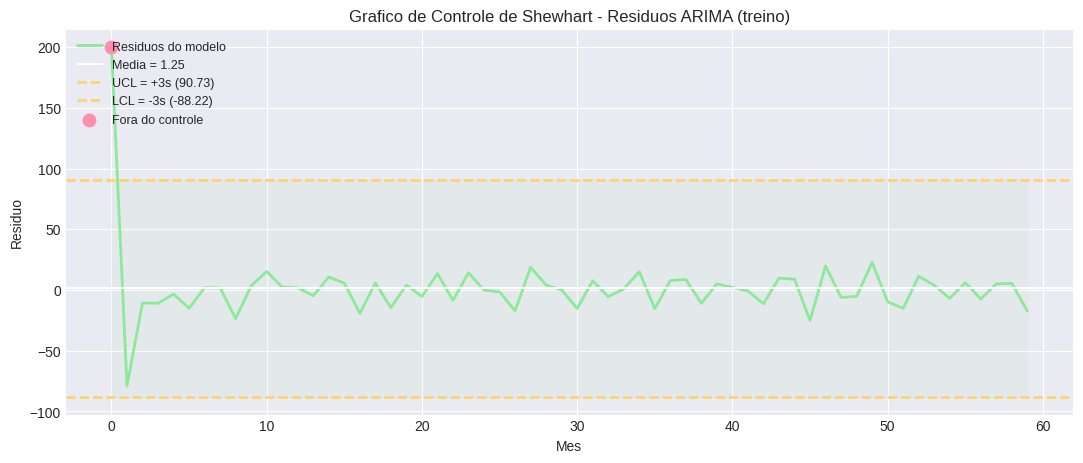

mu = 1.255  |  sigma = 29.824
UCL = 90.726  |  LCL = -88.216
Pontos fora do controle: 1 de 60


In [18]:
# CEP sobre os residuos do ARIMA no periodo de treino
fv_raw = resultado_arima.fittedvalues
fv     = np.asarray(fv_raw)
mask   = ~np.isnan(fv)
residuos_treino = y_train[mask] - fv[mask]
x_ref = x_train[mask]

mu_ref    = np.mean(residuos_treino)
sigma_ref = np.std(residuos_treino)
ucl = mu_ref + 3 * sigma_ref
lcl = mu_ref - 3 * sigma_ref

anomalias_idx = np.where((residuos_treino > ucl) | (residuos_treino < lcl))[0]

plt.figure(figsize=(13, 5))
plt.plot(x_ref, residuos_treino, color='#8ce99a', linewidth=2, label='Residuos do modelo')
plt.axhline(mu_ref, color='white', linewidth=1.4, linestyle='-',  label=f'Media = {mu_ref:.2f}')
plt.axhline(ucl,    color='#ffd166', linewidth=1.8, linestyle='--', label=f'UCL = +3s ({ucl:.2f})')
plt.axhline(lcl,    color='#ffd166', linewidth=1.8, linestyle='--', label=f'LCL = -3s ({lcl:.2f})')
if len(anomalias_idx) > 0:
    plt.scatter(x_ref[anomalias_idx], residuos_treino[anomalias_idx],
                color='#ff8fab', zorder=5, s=80, label='Fora do controle')
plt.fill_between(x_ref, lcl, ucl, color='#8ce99a', alpha=0.07)
plt.title('Grafico de Controle de Shewhart - Residuos ARIMA (treino)')
plt.xlabel('Mes')
plt.ylabel('Residuo')
plt.legend(loc='upper left', fontsize=9)
plt.show()

print(f'mu = {mu_ref:.3f}  |  sigma = {sigma_ref:.3f}')
print(f'UCL = {ucl:.3f}  |  LCL = {lcl:.3f}')
print(f'Pontos fora do controle: {len(anomalias_idx)} de {len(residuos_treino)}')

### Aplicando o CEP em producao: monitoramento pos-deploy

O modelo esta em producao. A cada mes o valor real chega e comparamos com o previsto.

Fluxo de trabalho:

1. **Treinar** o modelo com dados historicos
2. **Definir os limites** com base nos residuos do treino (mu +/- 3*sigma)
3. **Monitorar** cada nova observacao: `erro = real - previsto`
4. Se o erro cruzar UCL ou LCL: **alerta de anomalia** -> investigacao

| Dominio | O que monitorar |
|---|---|
| E-commerce | Desvio de demanda vs previsao de estoque |
| Fintech | Volume de transacoes vs previsto por hora |
| Plataformas de IA | Uso de GPU vs forecast |
| Manufatura | Quantidade produzida vs meta estatistica |

Mes  61: real=471.6  previsto=463.5  erro=+8.11  [OK]
Mes  62: real=484.8  previsto=480.5  erro=+4.34  [OK]
Mes  63: real=504.3  previsto=493.6  erro=+10.71  [OK]
Mes  64: real=502.0  previsto=500.5  erro=+1.51  [OK]
Mes  65: real=507.6  previsto=500.6  erro=+7.04  [OK]
Mes  66: real=504.9  previsto=495.0  erro=+9.95  [OK]
Mes  67: real=504.2  previsto=486.4  erro=+17.79  [OK]
Mes  68: real=496.7  previsto=478.3  erro=+18.36  [OK]
Mes  69: real=471.2  previsto=474.1  erro=-2.90  [OK]
Mes  70: real=476.1  previsto=476.0  erro=+0.15  [OK]
Mes  71: real=495.9  previsto=484.8  erro=+11.17  [OK]
Mes  72: real=489.6  previsto=499.2  erro=-9.62  [OK]


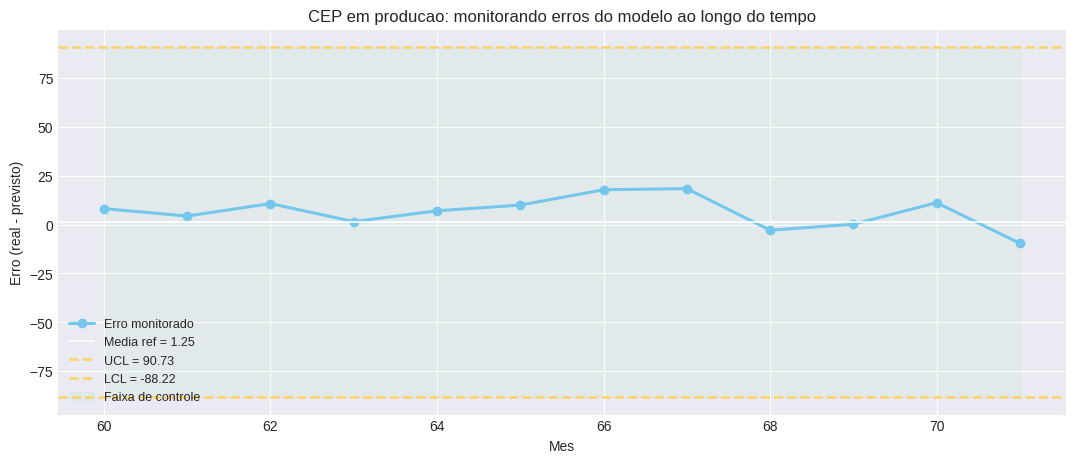


Alertas disparados: 0 de 12 meses monitorados


In [19]:
erros_monitorados = []
alertas = []

for i in range(len(y_test)):
    erro = y_test[i] - pred_test_arima[i]
    erros_monitorados.append(erro)
    status = 'ALERTA' if (erro > ucl or erro < lcl) else 'OK'
    if status == 'ALERTA':
        alertas.append(i)
    print(f'Mes {x_test[i]+1:>3}: real={y_test[i]:.1f}  previsto={pred_test_arima[i]:.1f}  erro={erro:+.2f}  [{status}]')

erros_monitorados = np.array(erros_monitorados)

plt.figure(figsize=(13, 5))
plt.plot(x_test, erros_monitorados, color='#74c7ec', linewidth=2.2, marker='o', label='Erro monitorado')
plt.axhline(mu_ref, color='white', linewidth=1.2, linestyle='-',   label=f'Media ref = {mu_ref:.2f}')
plt.axhline(ucl,    color='#ffd166', linewidth=1.8, linestyle='--', label=f'UCL = {ucl:.2f}')
plt.axhline(lcl,    color='#ffd166', linewidth=1.8, linestyle='--', label=f'LCL = {lcl:.2f}')
plt.fill_between(x_test, lcl, ucl, color='#8ce99a', alpha=0.08, label='Faixa de controle')
if alertas:
    plt.scatter(x_test[alertas], erros_monitorados[alertas],
                color='#ff8fab', zorder=5, s=100, label='ALERTA')
plt.title('CEP em producao: monitorando erros do modelo ao longo do tempo')
plt.xlabel('Mes')
plt.ylabel('Erro (real - previsto)')
plt.legend(fontsize=9)
plt.show()

print(f'\nAlertas disparados: {len(alertas)} de {len(y_test)} meses monitorados')

---

## 13. Conclusoes

| # | Conceito | Papel |
|---|---|---|
| 1 | Estatistica descritiva | Ler tendencia, sazonalidade e ruido antes de modelar |
| 2 | Regressao linear | Captura direcao global, ignora memoria temporal |
| 3 | ARIMA (AR + I + MA) | Modela dependencia temporal -> menor MAE |
| 4 | Distribuicao dos residuos | Histograma, QQ-plot e Shapiro-Wilk revelam calibracao |
| 5 | Intervalo de confianca | Comunica incerteza crescente com o horizonte |
| 6 | AIC / BIC | Selecao objetiva de ordem sem overfitting |
| 7 | CEP (Shewhart) | Transforma previsao em monitoramento continuo em producao |

### Pipeline completo

```
Dados historicos
    -> Analise exploratoria
    -> Selecao de modelo (AIC/BIC)
    -> Treinamento e validacao (MAE + residuos + normalidade)
    -> Deploy com previsao pontual + IC 95%
    -> Monitoramento com CEP (UCL/LCL)
    -> Alerta -> Investigacao -> Retreinamento
```

Prever o futuro nao e magia. E extrair padroes do passado com cuidado estatistico — e monitorar continuamente para detectar quando o padrao muda.